# PASO 4: Modelo 1 - Clasificación con ML para Late_delivery_risk

**Objetivo:** Entrenar el primer modelo real de Machine Learning para predecir la probabilidad de tardanza al momento del despacho, y compararlo contra el Baseline 2.

**Modelo:** Gradient Boosting (LightGBM) - robusto para datos tabulares

**Comparación:** Baseline 2 (tasas históricas) vs Modelo 1 (ML) usando las mismas métricas y split temporal.

## 1. Imports y Configuración

Librerías para manipulación de datos, preprocesamiento, modelado y evaluación.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Modelo
try:
    import lightgbm as lgb
except ModuleNotFoundError:
    import sys
    import subprocess

    print('Instalando lightgbm...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm'])
    import lightgbm as lgb

# Métricas
from sklearn.metrics import (
    precision_recall_curve,
    auc,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✓ Librerías cargadas')
print(f'LightGBM version: {lgb.__version__}')

✓ Librerías cargadas
LightGBM version: 4.6.0


## 2. Carga del Dataset Limpio

Cargar el dataset limpio del Paso 2 (`DataCoSupplyChainDataset_clean.csv`).

In [5]:
# Cargar dataset limpio
data_dir = Path('../data/processed')
df = pd.read_csv(data_dir / 'DataCoSupplyChainDataset_clean.csv')

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nPrimeras columnas: {list(df.columns[:15])}')

Dataset cargado: 180,519 filas × 35 columnas

Primeras columnas: ['Type', 'Days_for_shipping_(real)', 'Days_for_shipment_(scheduled)', 'Benefit_per_order', 'Sales_per_customer', 'Delivery_Status', 'Late_delivery_risk', 'Category_Id', 'Category_Name', 'Customer_City', 'Customer_Country', 'Customer_Id', 'Customer_Segment', 'Customer_State', 'Department_Id']


## 3. Parseo de Fecha de Despacho

Convertir `shipping_date_(DateOrders)` a datetime para permitir split temporal.

In [6]:
print('=== PARSEO DE FECHA ===\n')

# Parsear shipping_date
df['shipping_date_(DateOrders)'] = pd.to_datetime(df['shipping_date_(DateOrders)'], errors='coerce')

# Verificar parseo
nulos_fecha = df['shipping_date_(DateOrders)'].isna().sum()
pct_exitoso = (len(df) - nulos_fecha) / len(df) * 100

print(f'Parseo exitoso: {len(df) - nulos_fecha:,} / {len(df):,} ({pct_exitoso:.2f}%)')
print(f'Fecha mínima: {df["shipping_date_(DateOrders)"].min()}')
print(f'Fecha máxima: {df["shipping_date_(DateOrders)"].max()}')

# Eliminar filas sin fecha válida
if nulos_fecha > 0:
    print(f'\n⚠️ Eliminando {nulos_fecha:,} filas sin fecha válida')
    df = df.dropna(subset=['shipping_date_(DateOrders)'])
    
print(f'\n✓ Dataset con fechas válidas: {len(df):,} filas')

=== PARSEO DE FECHA ===

Parseo exitoso: 180,519 / 180,519 (100.00%)
Fecha mínima: 2015-01-03 00:00:00
Fecha máxima: 2018-02-06 22:14:00

✓ Dataset con fechas válidas: 180,519 filas


## 4. Filtro de Universo (Excluir Cancelados)

Excluir envíos con `Delivery_Status == "Shipping canceled"` para mantener consistencia con Baseline 2.

In [7]:
print('=== FILTRO DE UNIVERSO ===\n')
print(f'Filas antes del filtro: {len(df):,}')

# Verificar si existe Delivery_Status
if 'Delivery_Status' in df.columns:
    # Aplicar filtro
    df = df[~df['Delivery_Status'].str.contains('cancel', case=False, na=False)].copy()
    print(f'✓ Filas después de excluir cancelados: {len(df):,}')
else:
    print('⚠️ Columna Delivery_Status no encontrada - no se aplicó filtro')

# Eliminar nulos en target
if 'Late_delivery_risk' in df.columns:
    nulos_target = df['Late_delivery_risk'].isna().sum()
    if nulos_target > 0:
        print(f'\n⚠️ Eliminando {nulos_target:,} filas con target nulo')
        df = df.dropna(subset=['Late_delivery_risk'])

print(f'\n✓ Dataset final: {len(df):,} filas')

=== FILTRO DE UNIVERSO ===

Filas antes del filtro: 180,519
✓ Filas después de excluir cancelados: 172,765

✓ Dataset final: 172,765 filas


## 5. Split Temporal (Reproducir EXACTO del Baseline 2)

Particionar usando el mismo criterio temporal del Baseline 2: 80% train, 20% test por `shipping_date`.

In [8]:
print('=== SPLIT TEMPORAL (IDÉNTICO A BASELINE 2) ===\n')

# Ordenar por fecha
df_sorted = df.sort_values('shipping_date_(DateOrders)').reset_index(drop=True)

# Calcular punto de corte (80/20)
split_idx = int(len(df_sorted) * 0.8)

# Dividir train/test
train = df_sorted.iloc[:split_idx].copy()
test = df_sorted.iloc[split_idx:].copy()

print(f'📊 TRAIN SET:')
print(f'   Filas: {len(train):,} ({len(train)/len(df_sorted)*100:.1f}%)')
print(f'   Fecha min: {train["shipping_date_(DateOrders)"].min().date()}')
print(f'   Fecha max: {train["shipping_date_(DateOrders)"].max().date()}')
print(f'   Tardanzas: {train["Late_delivery_risk"].sum():,} ({train["Late_delivery_risk"].mean()*100:.2f}%)')

print(f'\n📊 TEST SET:')
print(f'   Filas: {len(test):,} ({len(test)/len(df_sorted)*100:.1f}%)')
print(f'   Fecha min: {test["shipping_date_(DateOrders)"].min().date()}')
print(f'   Fecha max: {test["shipping_date_(DateOrders)"].max().date()}')
print(f'   Tardanzas: {test["Late_delivery_risk"].sum():,} ({test["Late_delivery_risk"].mean()*100:.2f}%)')

print('\n✓ Split temporal completado (idéntico a Baseline 2)')

=== SPLIT TEMPORAL (IDÉNTICO A BASELINE 2) ===

📊 TRAIN SET:
   Filas: 138,212 (80.0%)
   Fecha min: 2015-01-03
   Fecha max: 2017-04-25
   Tardanzas: 79,130 (57.25%)

📊 TEST SET:
   Filas: 34,553 (20.0%)
   Fecha min: 2017-04-25
   Fecha max: 2018-02-06
   Tardanzas: 19,847 (57.44%)

✓ Split temporal completado (idéntico a Baseline 2)


## 6. Definición de Features (Sin Leakage)

**Features permitidas** (información disponible al momento del despacho):
- Numéricas: `Days_for_shipment_(scheduled)`, `processing_time`, `Order_Item_Quantity`, `Sales`, `Order_Item_Product_Price`
- Categóricas: `Shipping_Mode`, `Order_Region`, `Market`, `Order_Country`, `Order_State`, `Category_Name`
- Temporales: mes, día de semana, trimestre desde `shipping_date`

**Features PROHIBIDAS** (leakage):
- `Delivery_Status` - es el outcome final, no disponible al despacho
- `Days_for_shipping_(real)` - solo se conoce DESPUÉS de la entrega
- `Late_delivery_risk` - es el TARGET

In [9]:
print('=== DEFINICIÓN DE FEATURES ===\n')

# Target
target_col = 'Late_delivery_risk'

# Features prohibidas (leakage)
prohibited_features = [
    'Delivery_Status',
    'Days_for_shipping_(real)',
    'Late_delivery_risk'
]

# Features candidatas (numéricas)
numeric_features = [
    'Days_for_shipment_(scheduled)',
    'processing_time',
    'Order_Item_Quantity',
    'Sales',
    'Order_Item_Product_Price',
    'Order_Profit_Per_Order',
    'Product_Price'
]

# Features candidatas (categóricas)
categorical_features = [
    'Shipping_Mode',
    'Order_Region',
    'Market',
    'Order_Country',
    'Order_State',
    'Order_City',
    'Category_Name',
    'Department_Name',
    'Customer_Segment'
]

# Verificar cuáles existen en el dataset
numeric_features = [f for f in numeric_features if f in train.columns]
categorical_features = [f for f in categorical_features if f in train.columns]

print(f'✓ Features numéricas ({len(numeric_features)}):')
for feat in numeric_features:
    print(f'  - {feat}')

print(f'\n✓ Features categóricas ({len(categorical_features)}):')
for feat in categorical_features:
    nunique = train[feat].nunique()
    print(f'  - {feat} ({nunique} valores únicos)')

print(f'\n🚫 Features PROHIBIDAS (leakage):')
for feat in prohibited_features:
    print(f'  - {feat}')

=== DEFINICIÓN DE FEATURES ===

✓ Features numéricas (5):
  - Days_for_shipment_(scheduled)
  - processing_time
  - Order_Item_Quantity
  - Sales
  - Order_Item_Product_Price

✓ Features categóricas (9):
  - Shipping_Mode (4 valores únicos)
  - Order_Region (23 valores únicos)
  - Market (5 valores únicos)
  - Order_Country (164 valores únicos)
  - Order_State (1080 valores únicos)
  - Order_City (3534 valores únicos)
  - Category_Name (25 valores únicos)
  - Department_Name (6 valores únicos)
  - Customer_Segment (3 valores únicos)

🚫 Features PROHIBIDAS (leakage):
  - Delivery_Status
  - Days_for_shipping_(real)
  - Late_delivery_risk


## 7. Feature Engineering: Temporales desde shipping_date

Extraer componentes temporales de `shipping_date`: mes, día de semana, trimestre.

In [10]:
print('=== FEATURE ENGINEERING: TEMPORALES ===\n')

# Extraer features temporales en train
train['shipping_month'] = train['shipping_date_(DateOrders)'].dt.month
train['shipping_dayofweek'] = train['shipping_date_(DateOrders)'].dt.dayofweek
train['shipping_quarter'] = train['shipping_date_(DateOrders)'].dt.quarter
train['shipping_day'] = train['shipping_date_(DateOrders)'].dt.day

# Extraer features temporales en test
test['shipping_month'] = test['shipping_date_(DateOrders)'].dt.month
test['shipping_dayofweek'] = test['shipping_date_(DateOrders)'].dt.dayofweek
test['shipping_quarter'] = test['shipping_date_(DateOrders)'].dt.quarter
test['shipping_day'] = test['shipping_date_(DateOrders)'].dt.day

# Agregar a lista de features numéricas
temporal_features = ['shipping_month', 'shipping_dayofweek', 'shipping_quarter', 'shipping_day']
numeric_features.extend(temporal_features)

print(f'✓ Features temporales creadas: {temporal_features}')
print(f'✓ Total features numéricas ahora: {len(numeric_features)}')

=== FEATURE ENGINEERING: TEMPORALES ===

✓ Features temporales creadas: ['shipping_month', 'shipping_dayofweek', 'shipping_quarter', 'shipping_day']
✓ Total features numéricas ahora: 9


## 8. Preprocesamiento: Manejo de Nulos

Imputar valores faltantes en features numéricas con mediana (estrategia conservadora).

In [11]:
print('=== MANEJO DE NULOS: FEATURES NUMÉRICAS ===\n')

# Verificar nulos en train
nulos_train = train[numeric_features].isna().sum()
nulos_train = nulos_train[nulos_train > 0]

if len(nulos_train) > 0:
    print(f'Nulos en TRAIN (features numéricas):')
    print(nulos_train)
    
    # Imputar con mediana (ajustado solo en train)
    imputer = SimpleImputer(strategy='median')
    train[numeric_features] = imputer.fit_transform(train[numeric_features])
    test[numeric_features] = imputer.transform(test[numeric_features])
    
    print(f'\n✓ Nulos imputados con mediana (ajustado en TRAIN, aplicado a TEST)')
else:
    print('✓ No hay nulos en features numéricas')

# Verificar nulos después
print(f'\nNulos después de imputación:')
print(f'  Train: {train[numeric_features].isna().sum().sum()}')
print(f'  Test:  {test[numeric_features].isna().sum().sum()}')

=== MANEJO DE NULOS: FEATURES NUMÉRICAS ===

✓ No hay nulos en features numéricas

Nulos después de imputación:
  Train: 0
  Test:  0


## 9. Preprocesamiento: Encoding de Categóricas

Codificar features categóricas con Label Encoding (compatible con LightGBM), rellenando nulos con valor "Desconocido".

In [12]:
print('=== ENCODING DE CATEGÓRICAS ===\n')

# Primero: rellenar nulos con "Desconocido"
for col in categorical_features:
    train[col] = train[col].fillna('Desconocido').astype(str)
    test[col] = test[col].fillna('Desconocido').astype(str)

print(f'✓ Nulos rellenados con "Desconocido"')

# Label Encoding (ajustado en train, aplicado a test)
encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    
    # Ajustar en train
    le.fit(train[col])
    
    # Transformar train
    train[col + '_encoded'] = le.transform(train[col])
    
    # Transformar test (manejar categorías no vistas)
    test_values = test[col].copy()
    unseen_mask = ~test_values.isin(le.classes_)
    
    # Crear copia temporal para encoding
    test_values_safe = test_values.copy()
    if unseen_mask.sum() > 0:
        # Reemplazar no vistas con la primera clase conocida
        test_values_safe[unseen_mask] = le.classes_[0]
    
    test[col + '_encoded'] = le.transform(test_values_safe)
    
    # Marcar categorías no vistas con valor especial (-1)
    if unseen_mask.sum() > 0:
        test.loc[unseen_mask, col + '_encoded'] = -1
        print(f'  {col}: {unseen_mask.sum()} categorías no vistas en test → -1')
    
    encoders[col] = le

# Actualizar lista de features: reemplazar categóricas por sus versiones encoded
categorical_features_encoded = [f + '_encoded' for f in categorical_features]

print(f'\n✓ Label Encoding completado para {len(categorical_features)} categóricas')

=== ENCODING DE CATEGÓRICAS ===

✓ Nulos rellenados con "Desconocido"
  Order_State: 9 categorías no vistas en test → -1
  Order_City: 137 categorías no vistas en test → -1
  Category_Name: 9030 categorías no vistas en test → -1
  Department_Name: 4548 categorías no vistas en test → -1

✓ Label Encoding completado para 9 categóricas


## 10. Preparar Matrices X e y

Crear matrices de features (X) y target (y) para train y test.

In [13]:
print('=== PREPARACIÓN DE MATRICES X e y ===\n')

# Lista final de features
features_final = numeric_features + categorical_features_encoded

print(f'Features finales a usar: {len(features_final)}')
print(f'  Numéricas: {len(numeric_features)}')
print(f'  Categóricas (encoded): {len(categorical_features_encoded)}')

# Crear X e y para train
X_train = train[features_final].copy()
y_train = train[target_col].copy()

# Crear X e y para test
X_test = test[features_final].copy()
y_test = test[target_col].copy()

print(f'\n📊 Matrices creadas:')
print(f'   X_train: {X_train.shape}')
print(f'   y_train: {y_train.shape} (tardanzas: {y_train.sum():,}, {y_train.mean()*100:.2f}%)')
print(f'   X_test:  {X_test.shape}')
print(f'   y_test:  {y_test.shape} (tardanzas: {y_test.sum():,}, {y_test.mean()*100:.2f}%)')

# Verificar que no haya nulos
print(f'\nNulos en X_train: {X_train.isna().sum().sum()}')
print(f'Nulos en X_test:  {X_test.isna().sum().sum()}')

if X_train.isna().sum().sum() > 0 or X_test.isna().sum().sum() > 0:
    print('\n⚠️ Eliminando nulos restantes...')
    X_train = X_train.fillna(0)
    X_test = X_test.fillna(0)
    print('✓ Nulos eliminados (reemplazados por 0)')

print('\n✓ Matrices X e y listas para entrenamiento')

=== PREPARACIÓN DE MATRICES X e y ===

Features finales a usar: 18
  Numéricas: 9
  Categóricas (encoded): 9

📊 Matrices creadas:
   X_train: (138212, 18)
   y_train: (138212,) (tardanzas: 79,130, 57.25%)
   X_test:  (34553, 18)
   y_test:  (34553,) (tardanzas: 19,847, 57.44%)

Nulos en X_train: 0
Nulos en X_test:  0

✓ Matrices X e y listas para entrenamiento


## 11. Entrenar Modelo 1: LightGBM

Entrenar un clasificador Gradient Boosting (LightGBM) con parámetros conservadores (sin tuning complejo).

In [14]:
print('=== ENTRENAMIENTO: MODELO 1 (LightGBM) ===\n')

# Parámetros del modelo (conservadores, sin tuning)
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

# Crear datasets de LightGBM
train_data = lgb.Dataset(X_train, label=y_train)

print('Entrenando LightGBM...')
print(f'  Parámetros: learning_rate={params["learning_rate"]}, num_leaves={params["num_leaves"]}')

# Entrenar
model = lgb.train(
    params,
    train_data,
    num_boost_round=200,
    valid_sets=[train_data],
    valid_names=['train']
)

print(f'\n✓ Modelo entrenado con {model.num_trees()} árboles')

=== ENTRENAMIENTO: MODELO 1 (LightGBM) ===

Entrenando LightGBM...
  Parámetros: learning_rate=0.05, num_leaves=31

✓ Modelo entrenado con 200 árboles


## 12. Predicciones en Test

Generar probabilidades de tardanza (scores) en el conjunto de test.

In [15]:
print('=== PREDICCIONES EN TEST ===\n')

# Predecir probabilidades en test
y_pred_proba = model.predict(X_test, num_iteration=model.best_iteration)

print(f'✓ Predicciones generadas')
print(f'  Shape: {y_pred_proba.shape}')
print(f'  Min:    {y_pred_proba.min():.4f}')
print(f'  Max:    {y_pred_proba.max():.4f}')
print(f'  Media:  {y_pred_proba.mean():.4f}')
print(f'  Mediana: {np.median(y_pred_proba):.4f}')

# Agregar scores al dataframe de test
test['score_model'] = y_pred_proba

=== PREDICCIONES EN TEST ===

✓ Predicciones generadas
  Shape: (34553,)
  Min:    0.0001
  Max:    1.0000
  Media:  0.5698
  Mediana: 0.9998


## 13. Cargar Predicciones del Baseline 2

Cargar las predicciones del Baseline 2 para comparación (archivo `baseline2_predictions_test.csv`).

In [16]:
print('=== CARGA DE PREDICCIONES BASELINE 2 ===\n')

# Cargar baseline 2
baseline_path = data_dir / 'baseline2_predictions_test.csv'

if baseline_path.exists():
    baseline_preds = pd.read_csv(baseline_path)
    print(f'✓ Baseline 2 cargado: {len(baseline_preds):,} filas')
    
    # Verificar consistencia de tamaño
    if len(baseline_preds) == len(test):
        print(f'✓ Tamaño consistente con TEST ({len(test):,} filas)')
        
        # Agregar score del baseline al test (por orden)
        test['score_baseline2'] = baseline_preds['score_pred'].values
        
        print(f'\n✓ Scores de Baseline 2 agregados al dataframe de test')
    else:
        print(f'⚠️ ADVERTENCIA: Tamaños diferentes')
        print(f'  Baseline: {len(baseline_preds):,}')
        print(f'  Test:     {len(test):,}')
        raise ValueError('Tamaño inconsistente entre baseline y test')
else:
    print(f'❌ Archivo no encontrado: {baseline_path}')
    raise FileNotFoundError(f'Baseline 2 no disponible en {baseline_path}')

=== CARGA DE PREDICCIONES BASELINE 2 ===

✓ Baseline 2 cargado: 34,553 filas
✓ Tamaño consistente con TEST (34,553 filas)

✓ Scores de Baseline 2 agregados al dataframe de test


## 14. Evaluación: PR-AUC

Calcular el área bajo la curva Precision-Recall (PR-AUC) para ambos modelos.

=== EVALUACIÓN: PR-AUC ===

📊 PR-AUC en TEST:
   Baseline 2:  0.8368
   Modelo 1:    0.9989
   Mejora:      +0.1622 (+19.38%)


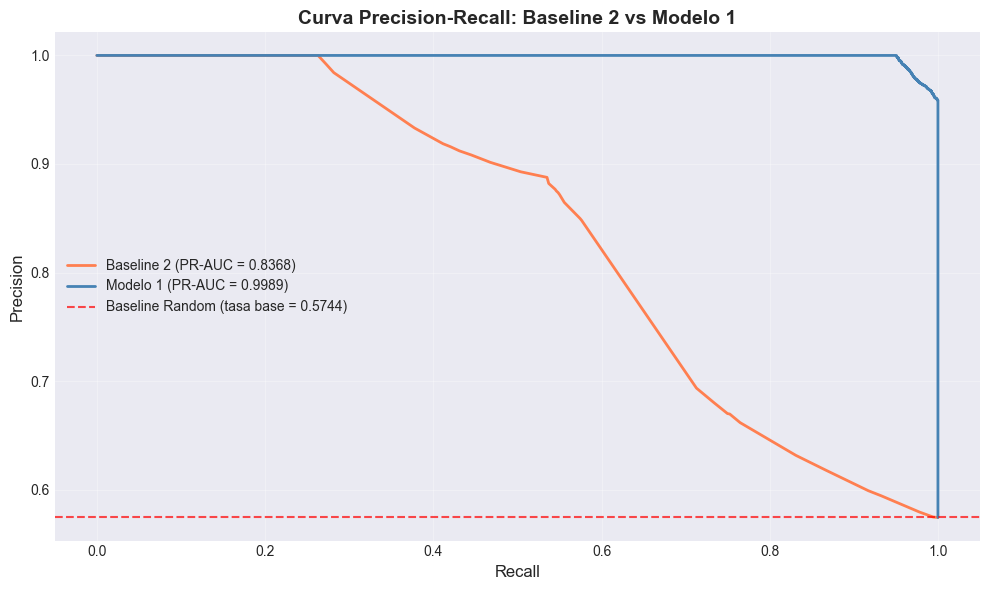

In [17]:
print('=== EVALUACIÓN: PR-AUC ===\n')

# Calcular PR-AUC para Baseline 2
precision_b2, recall_b2, _ = precision_recall_curve(y_test, test['score_baseline2'])
pr_auc_baseline2 = auc(recall_b2, precision_b2)

# Calcular PR-AUC para Modelo 1
precision_m1, recall_m1, _ = precision_recall_curve(y_test, test['score_model'])
pr_auc_model1 = auc(recall_m1, precision_m1)

print(f'📊 PR-AUC en TEST:')
print(f'   Baseline 2:  {pr_auc_baseline2:.4f}')
print(f'   Modelo 1:    {pr_auc_model1:.4f}')
print(f'   Mejora:      {pr_auc_model1 - pr_auc_baseline2:+.4f} ({(pr_auc_model1/pr_auc_baseline2 - 1)*100:+.2f}%)')

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(recall_b2, precision_b2, linewidth=2, 
        label=f'Baseline 2 (PR-AUC = {pr_auc_baseline2:.4f})', color='coral')
ax.plot(recall_m1, precision_m1, linewidth=2, 
        label=f'Modelo 1 (PR-AUC = {pr_auc_model1:.4f})', color='steelblue')
ax.axhline(y_test.mean(), color='red', linestyle='--', 
           linewidth=1.5, alpha=0.7, label=f'Baseline Random (tasa base = {y_test.mean():.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curva Precision-Recall: Baseline 2 vs Modelo 1', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Evaluación: Precision y Recall en Umbrales Fijos

Evaluar ambos modelos con umbrales predefinidos: 0.5 y Top 20% (percentil 80).

In [18]:
print('=== EVALUACIÓN: PRECISION Y RECALL EN UMBRALES ===\n')

# ========== UMBRAL 1: 0.5 ==========
threshold_50 = 0.5

# Baseline 2 con umbral 0.5
pred_b2_50 = (test['score_baseline2'] >= threshold_50).astype(int)
precision_b2_50 = precision_score(y_test, pred_b2_50)
recall_b2_50 = recall_score(y_test, pred_b2_50)

# Modelo 1 con umbral 0.5
pred_m1_50 = (test['score_model'] >= threshold_50).astype(int)
precision_m1_50 = precision_score(y_test, pred_m1_50)
recall_m1_50 = recall_score(y_test, pred_m1_50)

print(f'📌 UMBRAL = {threshold_50}:')
print(f'\n   Baseline 2:')
print(f'     Precision: {precision_b2_50:.4f}')
print(f'     Recall:    {recall_b2_50:.4f}')
print(f'     Alertas:   {pred_b2_50.sum():,} ({pred_b2_50.sum()/len(test)*100:.2f}%)')

print(f'\n   Modelo 1:')
print(f'     Precision: {precision_m1_50:.4f}')
print(f'     Recall:    {recall_m1_50:.4f}')
print(f'     Alertas:   {pred_m1_50.sum():,} ({pred_m1_50.sum()/len(test)*100:.2f}%)')

print(f'\n   Mejora:')
print(f'     Precision: {precision_m1_50 - precision_b2_50:+.4f}')
print(f'     Recall:    {recall_m1_50 - recall_b2_50:+.4f}')

# ========== UMBRAL 2: TOP 20% ==========
threshold_b2_p80 = test['score_baseline2'].quantile(0.80)
threshold_m1_p80 = test['score_model'].quantile(0.80)

# Baseline 2 con Top 20%
pred_b2_p80 = (test['score_baseline2'] >= threshold_b2_p80).astype(int)
precision_b2_p80 = precision_score(y_test, pred_b2_p80)
recall_b2_p80 = recall_score(y_test, pred_b2_p80)

# Modelo 1 con Top 20%
pred_m1_p80 = (test['score_model'] >= threshold_m1_p80).astype(int)
precision_m1_p80 = precision_score(y_test, pred_m1_p80)
recall_m1_p80 = recall_score(y_test, pred_m1_p80)

print(f'\n📌 UMBRAL = Top 20%:')
print(f'\n   Baseline 2 (score >= {threshold_b2_p80:.4f}):')
print(f'     Precision: {precision_b2_p80:.4f}')
print(f'     Recall:    {recall_b2_p80:.4f}')
print(f'     Alertas:   {pred_b2_p80.sum():,} ({pred_b2_p80.sum()/len(test)*100:.2f}%)')

print(f'\n   Modelo 1 (score >= {threshold_m1_p80:.4f}):')
print(f'     Precision: {precision_m1_p80:.4f}')
print(f'     Recall:    {recall_m1_p80:.4f}')
print(f'     Alertas:   {pred_m1_p80.sum():,} ({pred_m1_p80.sum()/len(test)*100:.2f}%)')

print(f'\n   Mejora:')
print(f'     Precision: {precision_m1_p80 - precision_b2_p80:+.4f}')
print(f'     Recall:    {recall_m1_p80 - recall_b2_p80:+.4f}')

=== EVALUACIÓN: PRECISION Y RECALL EN UMBRALES ===

📌 UMBRAL = 0.5:

   Baseline 2:
     Precision: 0.8751
     Recall:    0.5464
     Alertas:   12,393 (35.87%)

   Modelo 1:
     Precision: 0.9833
     Recall:    0.9689
     Alertas:   19,555 (56.59%)

   Mejora:
     Precision: +0.1082
     Recall:    +0.4224

📌 UMBRAL = Top 20%:

   Baseline 2 (score >= 0.8167):
     Precision: 0.9332
     Recall:    0.3777
     Alertas:   8,033 (23.25%)

   Modelo 1 (score >= 0.9999):
     Precision: 1.0000
     Recall:    0.3483
     Alertas:   6,912 (20.00%)

   Mejora:
     Precision: +0.0668
     Recall:    -0.0294


## 16. Tabla Comparativa: Baseline 2 vs Modelo 1

Resumen de todas las métricas en formato tabular para fácil comparación.

=== TABLA COMPARATIVA: BASELINE 2 vs MODELO 1 ===

               Métrica  Baseline_2  Modelo_1  Mejora  Mejora_%
                PR-AUC      0.8368    0.9989  0.1622   19.3805
Precision (umbral 0.5)      0.8751    0.9833  0.1082   12.3688
   Recall (umbral 0.5)      0.5464    0.9689  0.4224   77.3075
   Precision (Top 20%)      0.9332    1.0000  0.0668    7.1638
      Recall (Top 20%)      0.3777    0.3483 -0.0294   -7.7908


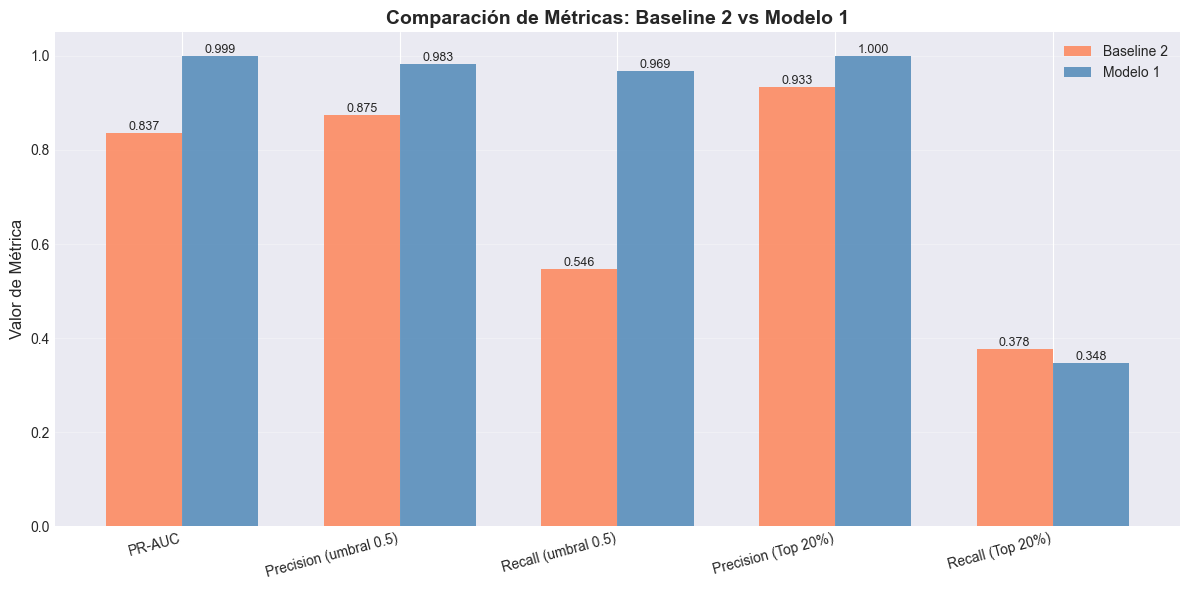

In [19]:
print('=== TABLA COMPARATIVA: BASELINE 2 vs MODELO 1 ===\n')

# Crear tabla de métricas
metrics_comparison = pd.DataFrame({
    'Métrica': [
        'PR-AUC',
        'Precision (umbral 0.5)',
        'Recall (umbral 0.5)',
        'Precision (Top 20%)',
        'Recall (Top 20%)'
    ],
    'Baseline_2': [
        pr_auc_baseline2,
        precision_b2_50,
        recall_b2_50,
        precision_b2_p80,
        recall_b2_p80
    ],
    'Modelo_1': [
        pr_auc_model1,
        precision_m1_50,
        recall_m1_50,
        precision_m1_p80,
        recall_m1_p80
    ]
})

# Calcular mejora
metrics_comparison['Mejora'] = metrics_comparison['Modelo_1'] - metrics_comparison['Baseline_2']
metrics_comparison['Mejora_%'] = (metrics_comparison['Modelo_1'] / metrics_comparison['Baseline_2'] - 1) * 100

# Mostrar tabla
print(metrics_comparison.to_string(index=False))

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

x = np.arange(len(metrics_comparison))
width = 0.35

bars1 = ax.bar(x - width/2, metrics_comparison['Baseline_2'], width, 
               label='Baseline 2', color='coral', alpha=0.8)
bars2 = ax.bar(x + width/2, metrics_comparison['Modelo_1'], width, 
               label='Modelo 1', color='steelblue', alpha=0.8)

ax.set_ylabel('Valor de Métrica', fontsize=12)
ax.set_title('Comparación de Métricas: Baseline 2 vs Modelo 1', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_comparison['Métrica'], rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 17. Interpretación de Resultados

Análisis cualitativo de la comparación Baseline 2 vs Modelo 1.

In [20]:
print('='*70)
print(' '*20 + 'INTERPRETACIÓN DE RESULTADOS')
print('='*70)

mejora_pr_auc_pct = (pr_auc_model1 / pr_auc_baseline2 - 1) * 100
mejora_precision_50_pct = (precision_m1_50 / precision_b2_50 - 1) * 100
mejora_recall_50_pct = (recall_m1_50 / recall_b2_50 - 1) * 100

print('\n🔍 HALLAZGOS PRINCIPALES:\n')

# Bullet 1: PR-AUC
if mejora_pr_auc_pct > 0:
    print(f'✓ El Modelo 1 SUPERA al Baseline 2 en PR-AUC ({mejora_pr_auc_pct:+.2f}%)')
    print(f'  → Mejor capacidad general para separar clases a través de todos los umbrales')
elif mejora_pr_auc_pct > -2:
    print(f'≈ El Modelo 1 tiene un PR-AUC similar al Baseline 2 ({mejora_pr_auc_pct:+.2f}%)')
    print(f'  → Performance comparable, considerar simplificar al baseline')
else:
    print(f'⚠️ El Modelo 1 NO supera al Baseline 2 en PR-AUC ({mejora_pr_auc_pct:+.2f}%)')
    print(f'  → El baseline histórico por segmento es más robusto')

# Bullet 2: Precision
if precision_m1_50 > precision_b2_50:
    print(f'\n✓ Mejor Precision en umbral 0.5: {precision_m1_50:.4f} vs {precision_b2_50:.4f}')
    print(f'  → Menos falsos positivos cuando alertamos tardanza')
else:
    print(f'\n⚠️ Menor Precision en umbral 0.5: {precision_m1_50:.4f} vs {precision_b2_50:.4f}')
    print(f'  → Más falsos positivos (alertas incorrectas)')

# Bullet 3: Recall
if recall_m1_50 > recall_b2_50:
    print(f'\n✓ Mejor Recall en umbral 0.5: {recall_m1_50:.4f} vs {recall_b2_50:.4f}')
    print(f'  → Detectamos más casos reales de tardanza')
else:
    print(f'\n⚠️ Menor Recall en umbral 0.5: {recall_m1_50:.4f} vs {recall_b2_50:.4f}')
    print(f'  → Perdemos más casos de tardanza (falsos negativos)')

# Bullet 4: Top 20%
if precision_m1_p80 > precision_b2_p80:
    print(f'\n✓ En Top 20% scores: Precision superior ({precision_m1_p80:.4f} vs {precision_b2_p80:.4f})')
    print(f'  → Sistema de alertas más preciso para casos de alto riesgo')
else:
    print(f'\n≈ En Top 20% scores: Precision similar ({precision_m1_p80:.4f} vs {precision_b2_p80:.4f})')

# Bullet 5: Conclusión
print(f'\n💡 CONCLUSIÓN:')
if mejora_pr_auc_pct > 2:
    print(f'   El Modelo 1 es RECOMENDABLE para producción.')
    print(f'   Justifica la complejidad adicional vs el baseline.')
elif mejora_pr_auc_pct > 0:
    print(f'   El Modelo 1 mejora marginalmente el baseline.')
    print(f'   Considerar costo-beneficio de implementar ML vs regla simple.')
else:
    print(f'   El Baseline 2 (tasas históricas) es suficiente por ahora.')
    print(f'   Explorar más features o modelos antes de implementar ML.')

print('\n' + '='*70)

                    INTERPRETACIÓN DE RESULTADOS

🔍 HALLAZGOS PRINCIPALES:

✓ El Modelo 1 SUPERA al Baseline 2 en PR-AUC (+19.38%)
  → Mejor capacidad general para separar clases a través de todos los umbrales

✓ Mejor Precision en umbral 0.5: 0.9833 vs 0.8751
  → Menos falsos positivos cuando alertamos tardanza

✓ Mejor Recall en umbral 0.5: 0.9689 vs 0.5464
  → Detectamos más casos reales de tardanza

✓ En Top 20% scores: Precision superior (1.0000 vs 0.9332)
  → Sistema de alertas más preciso para casos de alto riesgo

💡 CONCLUSIÓN:
   El Modelo 1 es RECOMENDABLE para producción.
   Justifica la complejidad adicional vs el baseline.



## 18. Feature Importance

Analizar las features más importantes según el modelo LightGBM.

=== FEATURE IMPORTANCE ===

Top 15 Features más importantes:

                      Feature  Importance
              processing_time 711640.0970
Days_for_shipment_(scheduled) 576178.6563
        Shipping_Mode_encoded 173583.0199
           Order_City_encoded   8896.0834
                 shipping_day   8170.5162
          Order_State_encoded   7934.1100
        Order_Country_encoded   5041.1128
               shipping_month   4549.8966
           shipping_dayofweek   4042.9071
         Order_Region_encoded   3121.2820
               Market_encoded   1348.1849
     Customer_Segment_encoded   1162.5309
             shipping_quarter    555.1068
                        Sales    272.7890
     Order_Item_Product_Price    211.1083


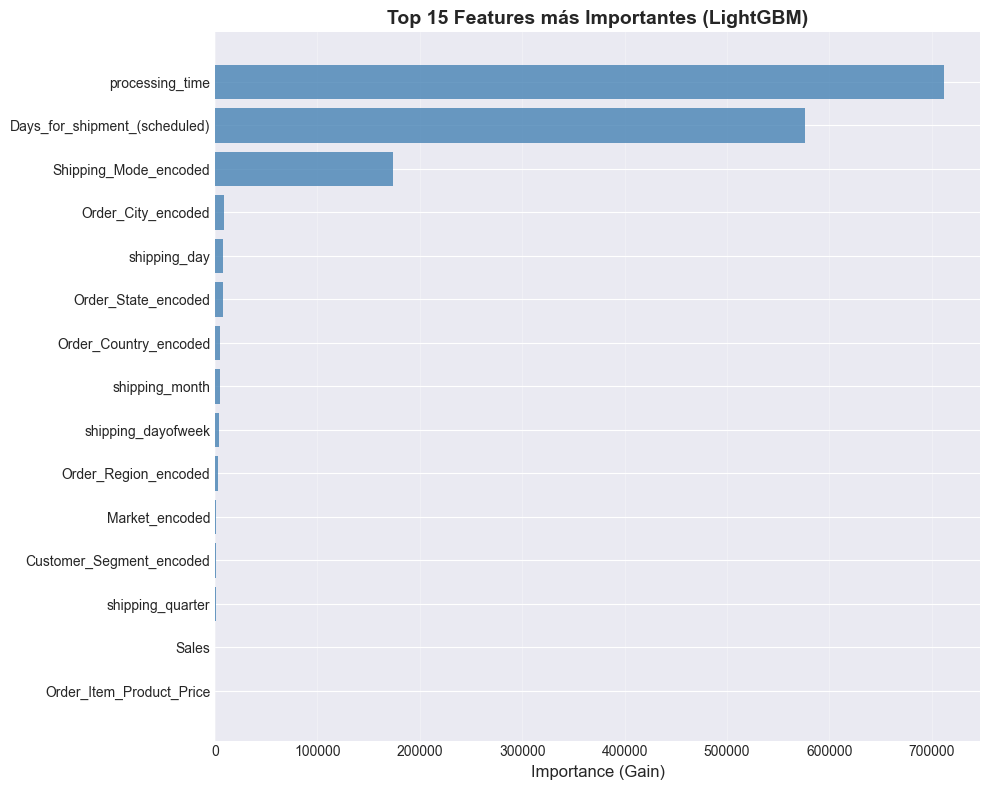

In [21]:
print('=== FEATURE IMPORTANCE ===\n')

# Obtener importancia de features
feature_importance = pd.DataFrame({
    'Feature': features_final,
    'Importance': model.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=False)

print('Top 15 Features más importantes:\n')
print(feature_importance.head(15).to_string(index=False))

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['Importance'], color='steelblue', alpha=0.8)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance (Gain)', fontsize=12)
ax.set_title('Top 15 Features más Importantes (LightGBM)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 19. Guardar Predicciones del Modelo 1

Exportar predicciones del Modelo 1 en test para análisis posteriores.

In [22]:
print('=== GUARDANDO PREDICCIONES DEL MODELO 1 ===\n')

# Preparar datos para guardar
predictions_model1 = test[[
    'shipping_date_(DateOrders)',
    'Late_delivery_risk',
    'score_model'
]].copy()

# Guardar
pred_path = data_dir / 'modelo1_predictions_test.csv'
predictions_model1.to_csv(pred_path, index=False)

print(f'✓ Predicciones guardadas: {pred_path}')
print(f'  Tamaño: {pred_path.stat().st_size / 1024:.2f} KB')
print(f'  Filas: {len(predictions_model1):,}')

=== GUARDANDO PREDICCIONES DEL MODELO 1 ===

✓ Predicciones guardadas: ..\data\processed\modelo1_predictions_test.csv
  Tamaño: 1464.44 KB
  Filas: 34,553


## 20. Guardar Tabla de Métricas Comparativa

Exportar tabla con todas las métricas Baseline 2 vs Modelo 1.

In [23]:
print('=== GUARDANDO TABLA DE MÉTRICAS ===\n')

# Guardar tabla de comparación
metrics_path = data_dir / 'modelo1_vs_baseline2_metrics.csv'
metrics_comparison.to_csv(metrics_path, index=False)

print(f'✓ Tabla de métricas guardada: {metrics_path}')
print(f'  Tamaño: {metrics_path.stat().st_size / 1024:.2f} KB')
print(f'  Filas: {len(metrics_comparison)}')

=== GUARDANDO TABLA DE MÉTRICAS ===

✓ Tabla de métricas guardada: ..\data\processed\modelo1_vs_baseline2_metrics.csv
  Tamaño: 0.49 KB
  Filas: 5


---

# RESUMEN FINAL: MODELO 1 vs BASELINE 2

---

In [24]:
print('='*70)
print(' '*15 + 'RESUMEN FINAL - MODELO 1')
print('='*70)

print('\n📊 DATASET Y SPLIT:')
print(f'   Dataset limpio: DataCoSupplyChainDataset_clean.csv')
print(f'   Universo: Excluidos envíos cancelados')
print(f'   Split temporal: 80/20 por shipping_date (idéntico a Baseline 2)')
print(f'   Train: {len(train):,} filas, {train["Late_delivery_risk"].mean()*100:.2f}% tardanzas')
print(f'   Test:  {len(test):,} filas, {test["Late_delivery_risk"].mean()*100:.2f}% tardanzas')

print('\n🎯 MODELO ENTRENADO:')
print(f'   Tipo: LightGBM (Gradient Boosting)')
print(f'   Features: {len(features_final)} ({len(numeric_features)} numéricas, {len(categorical_features)} categóricas)')
print(f'   Árboles: {model.num_trees()}')
print(f'   Top 3 features importantes:')
for i, row in feature_importance.head(3).iterrows():
    print(f'     {i+1}. {row["Feature"]}')

print('\n📈 COMPARACIÓN DE MÉTRICAS EN TEST:')
print(f'\n   {"Métrica":<25} {"Baseline 2":<12} {"Modelo 1":<12} {"Mejora":<12}')
print(f'   {"-"*25} {"-"*12} {"-"*12} {"-"*12}')
for _, row in metrics_comparison.iterrows():
    print(f'   {row["Métrica"]:<25} {row["Baseline_2"]:<12.4f} {row["Modelo_1"]:<12.4f} {row["Mejora"]:+<12.4f}')

print('\n💡 CONCLUSIÓN:')
if pr_auc_model1 > pr_auc_baseline2:
    mejora = (pr_auc_model1 / pr_auc_baseline2 - 1) * 100
    print(f'   ✓ El Modelo 1 SUPERA al Baseline 2 en PR-AUC (+{mejora:.2f}%)')
    print(f'   ✓ Justifica el uso de ML sobre reglas históricas simples')
else:
    print(f'   ≈ El Modelo 1 tiene performance similar al Baseline 2')
    print(f'   → Considerar si la complejidad adicional se justifica')

print('\n📁 ARCHIVOS GENERADOS:')
print(f'   - {pred_path.name}: predicciones en TEST')
print(f'   - {metrics_path.name}: tabla comparativa de métricas')

print('\n' + '='*70)
print(' '*12 + '✅ MODELO 1 COMPLETADO - LISTO PARA PASO 5')
print('='*70)
print(f'\n📌 SIGUIENTE PASO: Iterar mejoras (features, modelos, tuning)')

               RESUMEN FINAL - MODELO 1

📊 DATASET Y SPLIT:
   Dataset limpio: DataCoSupplyChainDataset_clean.csv
   Universo: Excluidos envíos cancelados
   Split temporal: 80/20 por shipping_date (idéntico a Baseline 2)
   Train: 138,212 filas, 57.25% tardanzas
   Test:  34,553 filas, 57.44% tardanzas

🎯 MODELO ENTRENADO:
   Tipo: LightGBM (Gradient Boosting)
   Features: 18 (9 numéricas, 9 categóricas)
   Árboles: 200
   Top 3 features importantes:
     2. processing_time
     1. Days_for_shipment_(scheduled)
     10. Shipping_Mode_encoded

📈 COMPARACIÓN DE MÉTRICAS EN TEST:

   Métrica                   Baseline 2   Modelo 1     Mejora      
   ------------------------- ------------ ------------ ------------
   PR-AUC                    0.8368       0.9989       0.1622++++++
   Precision (umbral 0.5)    0.8751       0.9833       0.1082++++++
   Recall (umbral 0.5)       0.5464       0.9689       0.4224++++++
   Precision (Top 20%)       0.9332       1.0000       0.0668++++++
   Rec